In [58]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({'font.size': 22})
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
import os


In [59]:
a = 0.3 # alpha. The smaller the alpha, the stronger the anisotropy 
J = a**4 / (48 * (3 - 2*a)**3) # the coupling constant of the effective toric code model
Jz = 1 - 2*a/3  # z-directional coupling
N = int(1e4) # system size

k = lambda T: np.tanh(Jz/T)
kJ = lambda T: np.tanh(J/T)
ksec = lambda T: 1/(np.cosh(Jz/T)**2) # 1 - k(T)**2
kJsec = lambda T: 1/(np.cosh(J/T)**2) # 1 - kJ(T)**2

def singularfunc(T, Jz=Jz):
    value = np.log(ksec(T) * np.exp(2*(1/T)*Jz*k(T)))
    return np.nan_to_num(value, nan=2*np.log(2))

def singularfuncJ(T,J=J):
    value = np.log(kJsec(T) * np.exp(2*(1/T)*J*kJ(T)))
    return np.nan_to_num(value, nan=2*np.log(2))

In [60]:
def lnZ(T, N=N):
    value = (N * np.log(2) 
             + np.log(1 
                      + 2 * k(T)**(N/2) * kJ(T)**(N/4) 
                      + kJ(T)**(N/2)) 
             - (N/4) * singularfunc(T)
             - (N/4) * singularfuncJ(T)
             )
    return value

def dlnZ(T, N=N, J=J, Jz=Jz):
    value = (kJ(T)**(N/4) 
             * (2 * (N/2) * k(T)**(N/2) * Jz * (1/k(T) - k(T))
                + 
                (N/2) * J * (k(T)**(N/2) + kJ(T)**(N/4)) * (1/kJ(T) - kJ(T)))
             / (1 + 2 * k(T)**(N/2) * kJ(T)**(N/4))
             )
             #+
             #(N/2) * k(T)
             #+
             #(N/2) * J * kJ(T))
    return value

def entropy(T):
    return lnZ(T) - (1/T)*dlnZ(T)

C:\Users\goodw\AppData\Local\Temp\ipykernel_12232\1266266040.py:8: RuntimeWarning: overflow encountered in cosh
  ksec = lambda T: 1/(np.cosh(Jz/T)**2) # 1 - k(T)**2
C:\Users\goodw\AppData\Local\Temp\ipykernel_12232\1266266040.py:8: RuntimeWarning: overflow encountered in square
  ksec = lambda T: 1/(np.cosh(Jz/T)**2) # 1 - k(T)**2
C:\Users\goodw\AppData\Local\Temp\ipykernel_12232\1266266040.py:12: RuntimeWarning: overflow encountered in exp
  value = np.log(ksec(T) * np.exp(2*(1/T)*Jz*k(T)))
C:\Users\goodw\AppData\Local\Temp\ipykernel_12232\1266266040.py:12: RuntimeWarning: invalid value encountered in multiply
  value = np.log(ksec(T) * np.exp(2*(1/T)*Jz*k(T)))


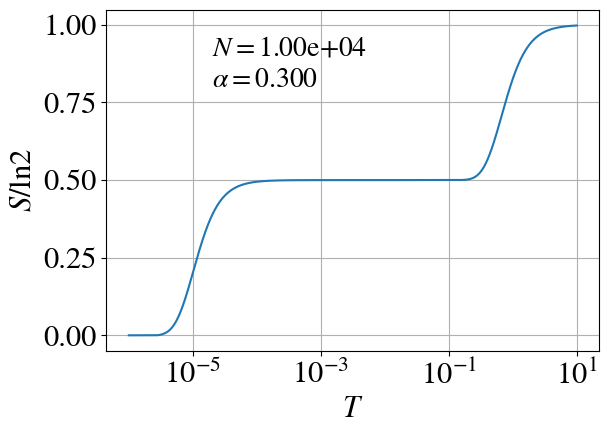

In [61]:
tscale = np.concatenate((np.linspace(start=1e-6, stop=1e-3, num=int(1e7))
                         , np.linspace(start=1e-3, stop=1e1, num=int(1e4))))
entropydata = entropy(T=tscale)/ N / np.log(2)

plt.semilogx(tscale, entropydata)
plt.xlabel(r'$T$')
plt.ylabel(r'$S/\mathrm{ln} 2$')
plt.text(.00002, .8, r'$\alpha=$' + '%.3f'%a, fontsize=20)
plt.text(.00002, .9, r'$N=$' + '%.2e'%N, fontsize=20)
plt.grid()

plt.tight_layout()
plt.savefig("alpha%.3f_N%.2e.pdf"%(a,N), dpi=300)
